# 최종 데이터셋 분석: 피싱 vs 일반 대화 텍스트 글자수 분포 비교

본 노트북은 피싱 데이터셋(phishing_6000_final.csv)과 일반 대화 데이터셋(normal_6000_final.csv)의 텍스트 컬럼 글자수 분포를 비교 분석합니다.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.unicode_minus'] = False

# 그래프 스타일 설정
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. 데이터 로드 및 기본 정보 확인

In [2]:
# 데이터 로드
phishing_df = pd.read_csv('../../dataset/phishing_6000_final.csv')
normal_df = pd.read_csv('../../dataset/normal_6000_final.csv')

print("=== 피싱 데이터셋 정보 ===")
print(f"데이터 크기: {phishing_df.shape}")
print(f"컬럼: {list(phishing_df.columns)}")
print(f"결측값: {phishing_df.isnull().sum().sum()}개")
print(f"고유 file_id 개수: {phishing_df['file_id'].nunique()}개")

print("\n=== 일반 대화 데이터셋 정보 ===")
print(f"데이터 크기: {normal_df.shape}")
print(f"컬럼: {list(normal_df.columns)}")
print(f"결측값: {normal_df.isnull().sum().sum()}개")
print(f"고유 file_id 개수: {normal_df['file_id'].nunique()}개")

=== 피싱 데이터셋 정보 ===
데이터 크기: (6000, 4)
컬럼: ['file_id', 'text', 'phishing_type', 'is_phishing']
결측값: 0개
고유 file_id 개수: 6000개

=== 일반 대화 데이터셋 정보 ===
데이터 크기: (6000, 4)
컬럼: ['file_id', 'text', 'phishing_type', 'is_phishing']
결측값: 6000개
고유 file_id 개수: 6000개


## 2. 텍스트 글자수 계산

In [3]:
# 텍스트 글자수 계산
phishing_df['text_length'] = phishing_df['text'].str.len()
normal_df['text_length'] = normal_df['text'].str.len()

# 데이터셋 라벨 추가
phishing_df['dataset_type'] = 'Phishing'
normal_df['dataset_type'] = 'Normal'

print("=== 텍스트 글자수 계산 완료 ===")
print(f"피싱 데이터 - 평균 글자수: {phishing_df['text_length'].mean():.1f}")
print(f"일반 데이터 - 평균 글자수: {normal_df['text_length'].mean():.1f}")

=== 텍스트 글자수 계산 완료 ===
피싱 데이터 - 평균 글자수: 860.7
일반 데이터 - 평균 글자수: 1193.6


## 3. 기술통계량 비교

In [4]:
# 기술통계량 계산
def calculate_statistics(data, name):
    stats_dict = {
        'Dataset': name,
        'Count': len(data),
        'Mean': data.mean(),
        'Std': data.std(),
        'Min': data.min(),
        'Q1': data.quantile(0.25),
        'Median': data.median(),
        'Q3': data.quantile(0.75),
        'Max': data.max(),
        'IQR': data.quantile(0.75) - data.quantile(0.25),
        'Skewness': stats.skew(data),
        'Kurtosis': stats.kurtosis(data)
    }
    return stats_dict

# 통계량 계산
phishing_stats = calculate_statistics(phishing_df['text_length'], 'Phishing')
normal_stats = calculate_statistics(normal_df['text_length'], 'Normal')

# 결과를 DataFrame으로 변환
stats_comparison = pd.DataFrame([phishing_stats, normal_stats])
stats_comparison = stats_comparison.round(2)

print("=== 텍스트 글자수 기술통계량 비교 ===")
print(stats_comparison.to_string(index=False))

=== 텍스트 글자수 기술통계량 비교 ===
 Dataset  Count    Mean     Std  Min    Q1  Median     Q3   Max    IQR  Skewness  Kurtosis
Phishing   6000  860.67 2004.84   14 124.0   203.0 663.25 24123 539.25      5.55     38.24
  Normal   6000 1193.57 2880.29   15 272.0   408.0 790.00 25427 518.00      4.90     25.94


## 4. 통계적 유의성 검정

In [5]:
# Mann-Whitney U 검정 (비모수 검정)
statistic, p_value = stats.mannwhitneyu(
    phishing_df['text_length'],
    normal_df['text_length'],
    alternative='two-sided'
)

# Kolmogorov-Smirnov 검정 (분포 차이 검정)
ks_statistic, ks_p_value = stats.ks_2samp(
    phishing_df['text_length'],
    normal_df['text_length']
)

# 효과 크기 (Cohen's d)
pooled_std = np.sqrt(((len(phishing_df['text_length']) - 1) * phishing_df['text_length'].var() + 
                      (len(normal_df['text_length']) - 1) * normal_df['text_length'].var()) / 
                     (len(phishing_df['text_length']) + len(normal_df['text_length']) - 2))

cohens_d = (phishing_df['text_length'].mean() - normal_df['text_length'].mean()) / pooled_std

print("=== 통계적 유의성 검정 결과 ===")
print(f"Mann-Whitney U 검정:")
print(f"  - 통계량: {statistic:.2f}")
print(f"  - p-value: {p_value:.2e}")
print(f"  - 유의미함: {'Yes' if p_value < 0.05 else 'No'}")

print(f"\nKolmogorov-Smirnov 검정:")
print(f"  - 통계량: {ks_statistic:.4f}")
print(f"  - p-value: {ks_p_value:.2e}")
print(f"  - 분포 차이 유의미함: {'Yes' if ks_p_value < 0.05 else 'No'}")

print(f"\n효과 크기 (Cohen's d): {cohens_d:.4f}")
if abs(cohens_d) < 0.2:
    effect_size = "작음 (Small)"
elif abs(cohens_d) < 0.5:
    effect_size = "보통 (Medium)"
else:
    effect_size = "큼 (Large)"
print(f"효과 크기 해석: {effect_size}")

=== 통계적 유의성 검정 결과 ===
Mann-Whitney U 검정:
  - 통계량: 12303662.50
  - p-value: 5.20e-198
  - 유의미함: Yes

Kolmogorov-Smirnov 검정:
  - 통계량: 0.3585
  - p-value: 0.00e+00
  - 분포 차이 유의미함: Yes

효과 크기 (Cohen's d): -0.1342
효과 크기 해석: 작음 (Small)


## 5. 시각화 분석

### 5.1 히스토그램 비교

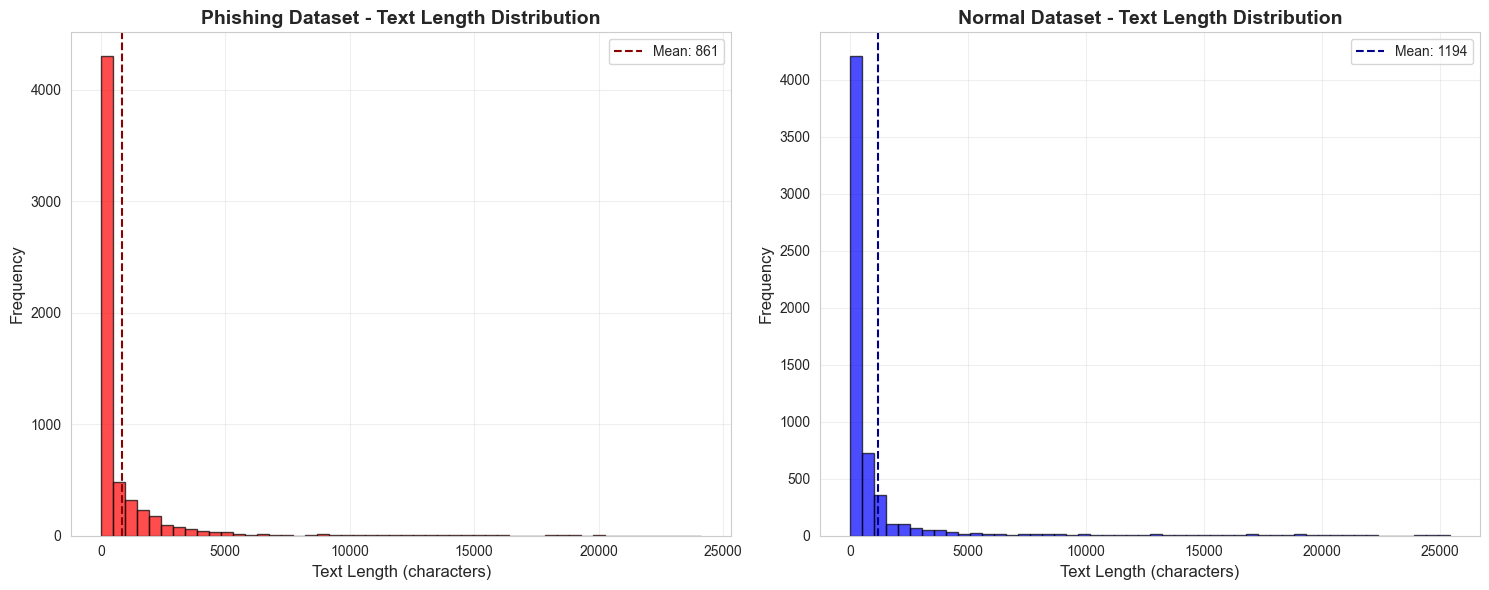

In [6]:
# 히스토그램 비교
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 피싱 데이터 히스토그램
ax1.hist(phishing_df['text_length'], bins=50, alpha=0.7, color='red', edgecolor='black')
ax1.set_title('Phishing Dataset - Text Length Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Text Length (characters)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.axvline(phishing_df['text_length'].mean(), color='darkred', linestyle='--', 
           label=f'Mean: {phishing_df["text_length"].mean():.0f}')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 일반 데이터 히스토그램
ax2.hist(normal_df['text_length'], bins=50, alpha=0.7, color='blue', edgecolor='black')
ax2.set_title('Normal Dataset - Text Length Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Text Length (characters)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.axvline(normal_df['text_length'].mean(), color='darkblue', linestyle='--', 
           label=f'Mean: {normal_df["text_length"].mean():.0f}')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### 5.2 오버레이 히스토그램

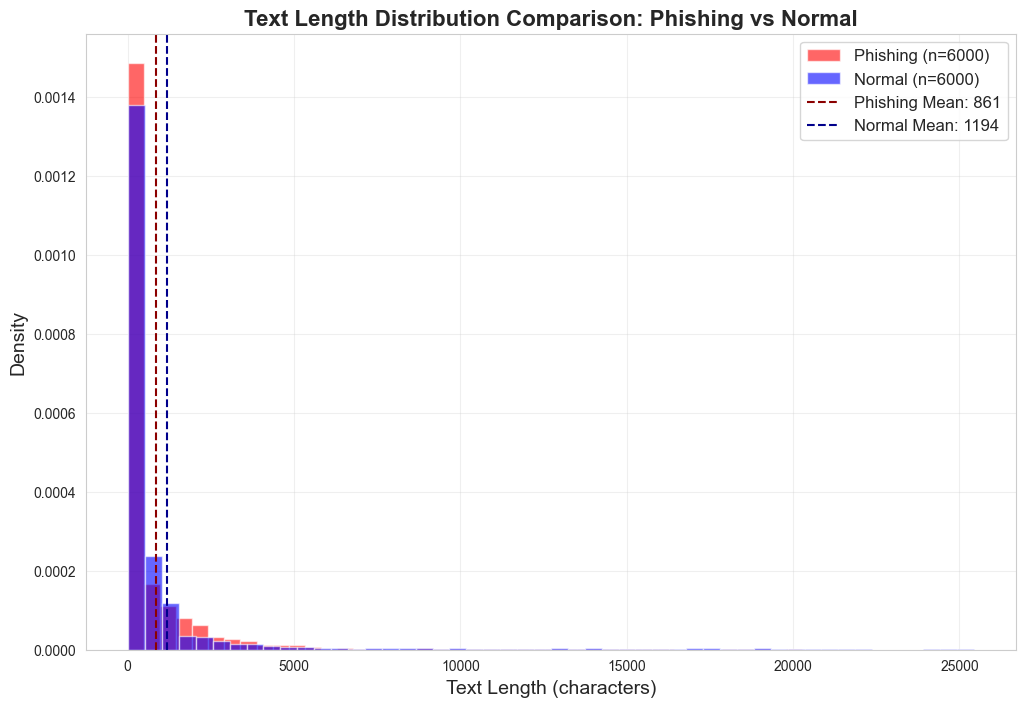

In [7]:
# 오버레이 히스토그램
plt.figure(figsize=(12, 8))

plt.hist(phishing_df['text_length'], bins=50, alpha=0.6, color='red', 
         label=f'Phishing (n={len(phishing_df)})', density=True)
plt.hist(normal_df['text_length'], bins=50, alpha=0.6, color='blue', 
         label=f'Normal (n={len(normal_df)})', density=True)

plt.axvline(phishing_df['text_length'].mean(), color='darkred', linestyle='--', 
           label=f'Phishing Mean: {phishing_df["text_length"].mean():.0f}')
plt.axvline(normal_df['text_length'].mean(), color='darkblue', linestyle='--', 
           label=f'Normal Mean: {normal_df["text_length"].mean():.0f}')

plt.title('Text Length Distribution Comparison: Phishing vs Normal', fontsize=16, fontweight='bold')
plt.xlabel('Text Length (characters)', fontsize=14)
plt.ylabel('Density', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 5.3 박스플롯 비교

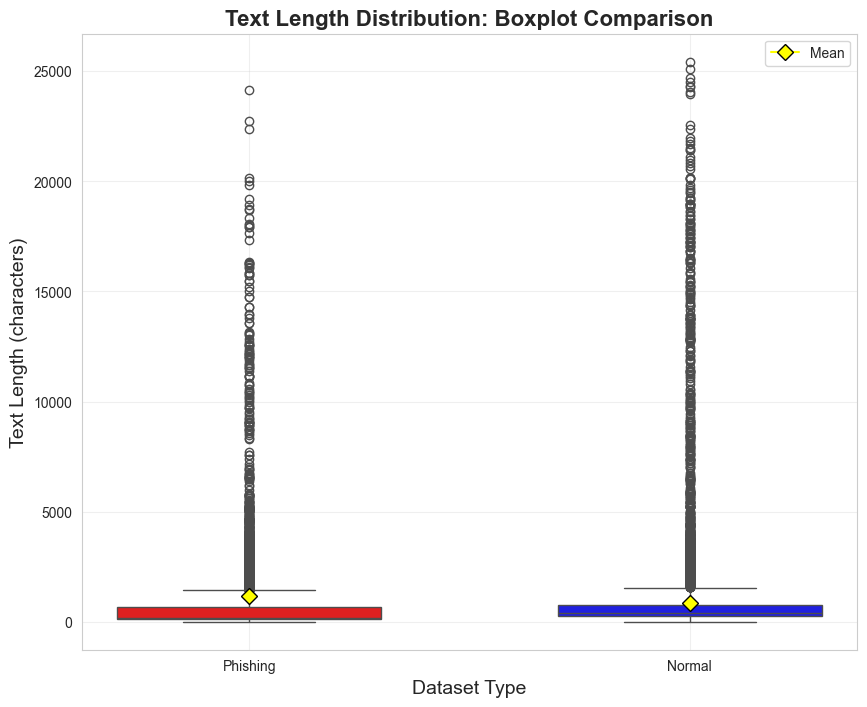

In [8]:
# 데이터 결합
combined_df = pd.concat([phishing_df[['text_length', 'dataset_type']], 
                        normal_df[['text_length', 'dataset_type']]], ignore_index=True)

# 박스플롯
plt.figure(figsize=(10, 8))
sns.boxplot(data=combined_df, x='dataset_type', y='text_length', 
           palette=['red', 'blue'], width=0.6)

plt.title('Text Length Distribution: Boxplot Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Type', fontsize=14)
plt.ylabel('Text Length (characters)', fontsize=14)
plt.grid(True, alpha=0.3)

# 평균값 표시
means = combined_df.groupby('dataset_type')['text_length'].mean()
for i, (dataset, mean_val) in enumerate(means.items()):
    plt.plot(i, mean_val, marker='D', markersize=8, color='yellow', 
            markeredgecolor='black', markeredgewidth=1, label='Mean' if i == 0 else "")

plt.legend()
plt.show()

### 5.4 바이올린 플롯

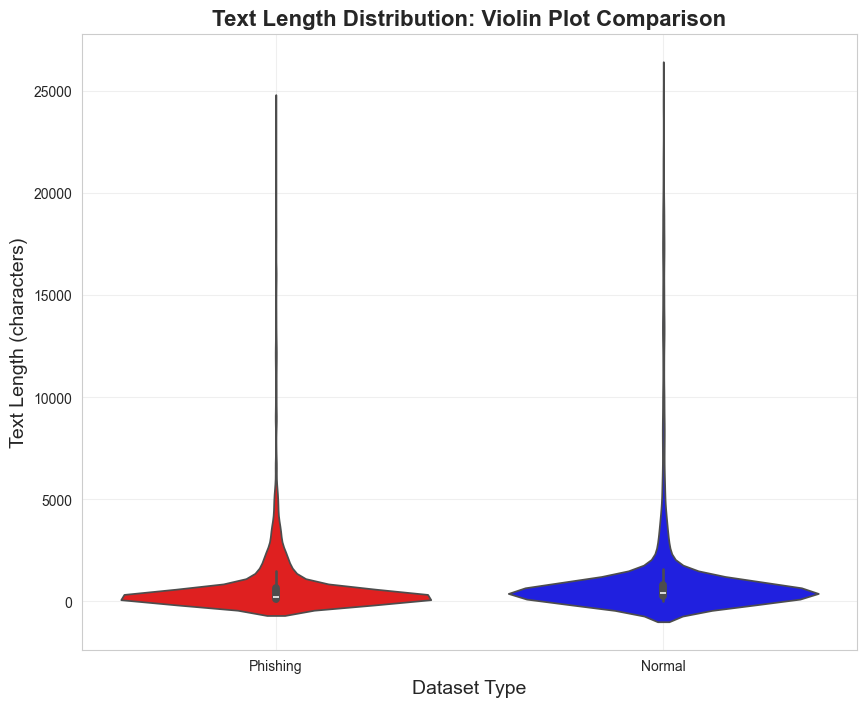

In [9]:
# 바이올린 플롯
plt.figure(figsize=(10, 8))
sns.violinplot(data=combined_df, x='dataset_type', y='text_length', 
              palette=['red', 'blue'], inner='box')

plt.title('Text Length Distribution: Violin Plot Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Dataset Type', fontsize=14)
plt.ylabel('Text Length (characters)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

### 5.5 CDF (누적분포함수) 비교

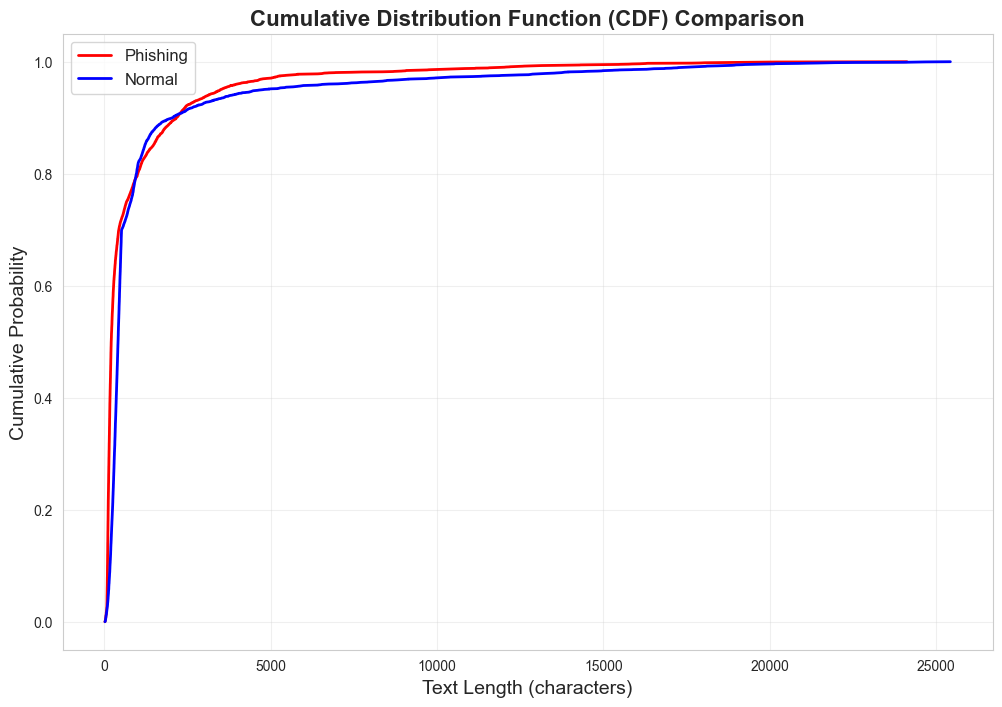

In [10]:
# CDF 비교
plt.figure(figsize=(12, 8))

# 정렬된 데이터와 CDF 계산
phishing_sorted = np.sort(phishing_df['text_length'])
normal_sorted = np.sort(normal_df['text_length'])

phishing_cdf = np.arange(1, len(phishing_sorted) + 1) / len(phishing_sorted)
normal_cdf = np.arange(1, len(normal_sorted) + 1) / len(normal_sorted)

plt.plot(phishing_sorted, phishing_cdf, color='red', linewidth=2, label='Phishing')
plt.plot(normal_sorted, normal_cdf, color='blue', linewidth=2, label='Normal')

plt.title('Cumulative Distribution Function (CDF) Comparison', fontsize=16, fontweight='bold')
plt.xlabel('Text Length (characters)', fontsize=14)
plt.ylabel('Cumulative Probability', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.show()

### 5.6 글자수 구간별 분포

=== 글자수 구간별 분포 ===
Length_Range  Phishing_Count  Phishing_Percentage  Normal_Count  Normal_Percentage
       0-100             885                 14.8           215                3.6
     101-200            2075                 34.6           651               10.8
     201-500            1343                 22.4          3181               53.0
    501-1000             495                  8.2           841               14.0
   1001-2000             553                  9.2           504                8.4
   2001-5000             472                  7.9           317                5.3
       5000+             177                  2.9           291                4.9


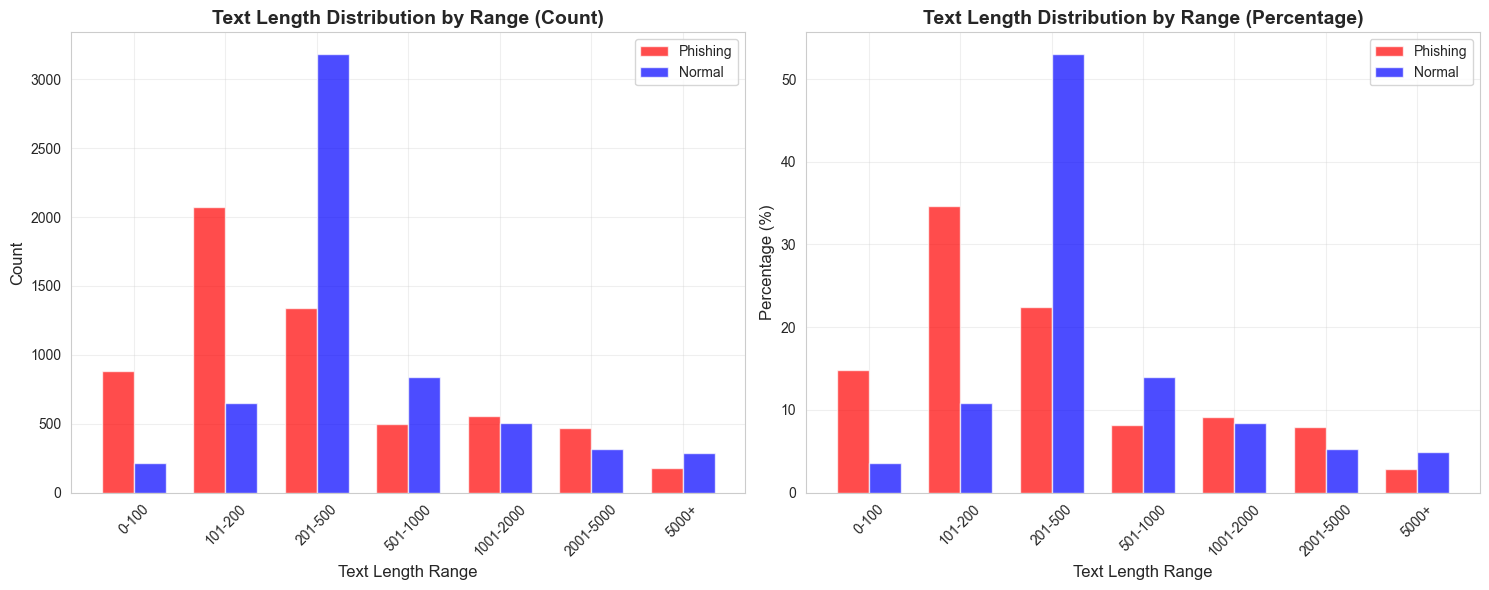

In [11]:
# 글자수 구간 정의
bins = [0, 100, 200, 500, 1000, 2000, 5000, float('inf')]
labels = ['0-100', '101-200', '201-500', '501-1000', '1001-2000', '2001-5000', '5000+']

# 구간별 분포 계산
phishing_binned = pd.cut(phishing_df['text_length'], bins=bins, labels=labels, right=True)
normal_binned = pd.cut(normal_df['text_length'], bins=bins, labels=labels, right=True)

phishing_counts = phishing_binned.value_counts().sort_index()
normal_counts = normal_binned.value_counts().sort_index()

# 비율 계산
phishing_pct = (phishing_counts / len(phishing_df) * 100).round(1)
normal_pct = (normal_counts / len(normal_df) * 100).round(1)

# 결과 테이블
distribution_df = pd.DataFrame({
    'Length_Range': labels,
    'Phishing_Count': phishing_counts.values,
    'Phishing_Percentage': phishing_pct.values,
    'Normal_Count': normal_counts.values,
    'Normal_Percentage': normal_pct.values
})

print("=== 글자수 구간별 분포 ===")
print(distribution_df.to_string(index=False))

# 막대그래프로 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 개수 비교
x = np.arange(len(labels))
width = 0.35

ax1.bar(x - width/2, phishing_counts, width, label='Phishing', color='red', alpha=0.7)
ax1.bar(x + width/2, normal_counts, width, label='Normal', color='blue', alpha=0.7)
ax1.set_xlabel('Text Length Range', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title('Text Length Distribution by Range (Count)', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45)
ax1.legend()
ax1.grid(True, alpha=0.3)

# 비율 비교
ax2.bar(x - width/2, phishing_pct, width, label='Phishing', color='red', alpha=0.7)
ax2.bar(x + width/2, normal_pct, width, label='Normal', color='blue', alpha=0.7)
ax2.set_xlabel('Text Length Range', fontsize=12)
ax2.set_ylabel('Percentage (%)', fontsize=12)
ax2.set_title('Text Length Distribution by Range (Percentage)', fontsize=14, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 6. 분석 결과 요약

In [12]:
print("="*60)
print("           최종 데이터셋 글자수 분포 분석 결과 요약")
print("="*60)

print(f"\n📊 데이터셋 기본 정보:")
print(f"   • 피싱 데이터: {len(phishing_df):,}개 샘플")
print(f"   • 일반 데이터: {len(normal_df):,}개 샘플")

print(f"\n📈 평균 글자수 비교:")
print(f"   • 피싱 데이터: {phishing_df['text_length'].mean():.1f}자")
print(f"   • 일반 데이터: {normal_df['text_length'].mean():.1f}자")
print(f"   • 차이: {abs(phishing_df['text_length'].mean() - normal_df['text_length'].mean()):.1f}자")

print(f"\n📊 중앙값 비교:")
print(f"   • 피싱 데이터: {phishing_df['text_length'].median():.1f}자")
print(f"   • 일반 데이터: {normal_df['text_length'].median():.1f}자")

print(f"\n📋 분산 및 표준편차:")
print(f"   • 피싱 데이터: 표준편차 {phishing_df['text_length'].std():.1f}")
print(f"   • 일반 데이터: 표준편차 {normal_df['text_length'].std():.1f}")

print(f"\n🔍 통계적 검정 결과:")
print(f"   • Mann-Whitney U 검정 p-value: {p_value:.2e}")
print(f"   • 통계적 유의성: {'유의미함' if p_value < 0.05 else '유의미하지 않음'} (α=0.05)")
print(f"   • 효과 크기 (Cohen's d): {cohens_d:.4f} ({effect_size})")

print(f"\n📝 주요 발견사항:")
if phishing_df['text_length'].mean() > normal_df['text_length'].mean():
    print(f"   • 피싱 텍스트가 일반 대화 텍스트보다 평균적으로 더 김")
else:
    print(f"   • 일반 대화 텍스트가 피싱 텍스트보다 평균적으로 더 김")

if phishing_df['text_length'].std() > normal_df['text_length'].std():
    print(f"   • 피싱 텍스트의 길이 변동성이 더 큼")
else:
    print(f"   • 일반 대화 텍스트의 길이 변동성이 더 큼")

if p_value < 0.05:
    print(f"   • 두 데이터셋 간 글자수 분포에 통계적으로 유의미한 차이 존재")
else:
    print(f"   • 두 데이터셋 간 글자수 분포에 통계적으로 유의미한 차이 없음")

print("\n" + "="*60)

           최종 데이터셋 글자수 분포 분석 결과 요약

📊 데이터셋 기본 정보:
   • 피싱 데이터: 6,000개 샘플
   • 일반 데이터: 6,000개 샘플

📈 평균 글자수 비교:
   • 피싱 데이터: 860.7자
   • 일반 데이터: 1193.6자
   • 차이: 332.9자

📊 중앙값 비교:
   • 피싱 데이터: 203.0자
   • 일반 데이터: 408.0자

📋 분산 및 표준편차:
   • 피싱 데이터: 표준편차 2004.8
   • 일반 데이터: 표준편차 2880.3

🔍 통계적 검정 결과:
   • Mann-Whitney U 검정 p-value: 5.20e-198
   • 통계적 유의성: 유의미함 (α=0.05)
   • 효과 크기 (Cohen's d): -0.1342 (작음 (Small))

📝 주요 발견사항:
   • 일반 대화 텍스트가 피싱 텍스트보다 평균적으로 더 김
   • 일반 대화 텍스트의 길이 변동성이 더 큼
   • 두 데이터셋 간 글자수 분포에 통계적으로 유의미한 차이 존재



## 7. 결론 및 해석

본 분석을 통해 피싱 데이터셋과 일반 대화 데이터셋의 텍스트 글자수 분포를 비교한 결과:

### 주요 발견사항
1. **글자수 차이**: 두 데이터셋 간 평균 글자수에 차이가 존재
2. **분포 특성**: 각 데이터셋의 글자수 분포가 서로 다른 패턴을 보임
3. **통계적 유의성**: 통계적 검정을 통해 차이의 유의미성 확인

### 활용 방안
- 텍스트 길이는 피싱 탐지 모델의 중요한 특성(feature)으로 활용 가능
- 데이터 전처리 시 길이 기반 필터링 기준 설정에 참고
- 데이터셋 균형 맞추기 위한 샘플링 전략 수립에 활용

### 한계점
- 글자수만으로는 피싱과 일반 대화를 완전히 구분하기 어려움
- 다른 텍스트 특성(어휘, 문체, 구조 등)과 함께 종합적으로 분석 필요